### Size issue 
That file size of 28.45 GB for a single-cell RNA-seq .h5ad dataset is very large.

Memory (RAM): A 28 GB .h5ad file, which typically contains a sparse matrix of UMI counts, will require a substantial amount of RAM when loaded and processed. When the data is converted to a dense matrix or intermediate processing steps are performed (like calculating nearest neighbors, running PCA, etc.), the memory footprint can easily exceed 100-200 GB.

Processing Time: Even with sufficient RAM, a dataset of this size (likely involving millions of cells) will result in long processing times for any single-cell workflow, particularly for computationally intensive steps like training a large neural network model such as GenFormer.

In [2]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import cellxgene_census
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

In [2]:
 adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq.h5ad')

In [5]:
 adata_an = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq_annotated.h5ad')

In [5]:
 adata_re = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq_retracted_20240202.h5ad')

In [11]:
adata

AnnData object with n_obs × n_vars = 2441192 × 40496
    obs: 'sample_id', 'participant_id'
    uns: 'genome', 'modality', 'uid', 'var_dict'

In [6]:
# this is the one that we need to utilise 
adata_an

AnnData object with n_obs × n_vars = 2096155 × 40496
    obs: 'sample_id', 'participant_id', 'cell_type'
    uns: 'genome', 'modality', 'uid', 'var_dict'

In [9]:
adata_re

AnnData object with n_obs × n_vars = 2441192 × 40496
    obs: 'sample_id', 'participant_id'
    uns: 'genome', 'modality', 'var_dict'

In [3]:
braak = pd.read_csv("/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/clinical_Terra_2024_v4_release_1027/LBD_Cohort_Path_Data.csv")

In [4]:
braak

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
0,LB-00001,NaN,M0,0,NaN,NaN,NaN,NaN
1,LB-00002,NaN,M0,0,NaN,NaN,NaN,NaN
2,LB-00003,NaN,M0,0,NaN,NaN,NaN,NaN
3,LB-00004,NaN,M0,0,NaN,NaN,NaN,NaN
4,LB-00005,NaN,M0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN


In [7]:
len(adata_an.obs['participant_id'].unique())

97

In [8]:
# getting unique column ID 

participant_ids = adata_an.obs['participant_id'].unique()

In [9]:
participant_ids

['PM-UM_BEB19139', 'PM-UD_11485_001', 'PM-UD_1052_001', 'PM-MS_841919', 'PM-UM_BEB20014', ..., 'PM-HA_S06947', 'PM-HA_S16298', 'PM-HA_S07792', 'PM-MS_971551', 'PM-MS_56356']
Length: 97
Categories (97, object): ['PM-UM_BEB18119', 'PM-UM_BEB18140', 'PM-UM_BEB19010', 'PM-UM_BEB19108', ..., 'PM-HA_S16962', 'PM-HA_S18739', 'PM-HA_S19010', 'PM-HA_S19871']

In [8]:
braak.columns

Index(['participant_id', 'GUID', 'visit_name', 'visit_month', 'path_cerad',
       'path_braak_nft', 'path_braak_lb', 'path_dlb_prob'],
      dtype='object')

In [9]:
# filter the clinical data

braak_filtered = braak[braak['participant_id'].isin(participant_ids)]

In [12]:
data_i = braak_filtered.sort_index()

In [13]:
data_i

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN
...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN


# analysing the data nft and lb 

In [15]:
data_i["path_braak_lb"].value_counts()


path_braak_lb
4.0    24
5.0    21
3.0    18
6.0     7
0.0     7
1.0     4
2.0     4
Name: count, dtype: int64

In [16]:
data_i["path_braak_nft"].value_counts()

path_braak_nft
1.0    38
2.0    23
3.0    15
0.0     6
Name: count, dtype: int64

In [17]:
# Define groups (VERY useful)
high_lb = data_i[data_i["path_braak_lb"] >= 4]
low_lb  = data_i[data_i["path_braak_lb"] < 4]

In [18]:
high_lb

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN
2529,PM-HA_S05527,NaN,M0,0,NaN,1.0,4.0,NaN
2530,PM-HA_S05887,NaN,M0,0,NaN,2.0,5.0,NaN
2531,PM-HA_S06947,NaN,M0,0,NaN,1.0,4.0,NaN
2532,PM-HA_S07532,NaN,M0,0,NaN,1.0,4.0,NaN
2534,PM-HA_S07792,NaN,M0,0,NaN,1.0,4.0,NaN


In [19]:
low_lb

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2526,PM-HA_S02971,NaN,M0,0,NaN,2.0,3.0,NaN
2528,PM-HA_S04610,NaN,M0,0,NaN,1.0,2.0,NaN
2533,PM-HA_S07555,NaN,M0,0,NaN,1.0,3.0,NaN
2539,PM-HA_S14032,NaN,M0,0,NaN,1.0,3.0,NaN
2541,PM-HA_S16580,NaN,M0,0,NaN,1.0,3.0,NaN
2544,PM-HA_S19010,NaN,M0,0,NaN,1.0,3.0,NaN
2546,PM-MS_17629,NaN,SC#1,-5,NaN,1.0,2.0,Low Likelihood
2547,PM-MS_46475,NaN,SC#1,-1,NaN,1.0,1.0,Low Likelihood
2548,PM-MS_458379,NaN,SC#1,-4,NaN,1.0,1.0,Low Likelihood
2550,PM-MS_840752,NaN,SC#1,-1,NaN,1.0,1.0,Low Likelihood


In [20]:
# Tau severity:
high_tau = data_i[data_i["path_braak_nft"] >= 3]
low_tau  = data_i[data_i["path_braak_nft"] < 3]

In [21]:
high_tau

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2535,PM-HA_S08385,NaN,M0,0,NaN,3.0,4.0,NaN
2552,PM-MS_38636,NaN,SC#1,-9,NaN,3.0,3.0,Low Likelihood
2556,PM-MS_6130,NaN,SC#1,-3,NaN,3.0,5.0,Low Likelihood
2572,PM-UD_11609_001,NaN,M0,0,NaN,3.0,3.0,NaN
2578,PM-UD_11363_001,NaN,M0,0,NaN,3.0,5.0,NaN
2579,PM-UD_11398_001,NaN,M0,0,NaN,3.0,5.0,NaN
2581,PM-UD_11466_001,NaN,M0,0,NaN,3.0,5.0,NaN
2582,PM-UD_11494_001,NaN,M0,0,NaN,3.0,5.0,NaN
2583,PM-UD_11610_001,NaN,M0,0,NaN,3.0,6.0,NaN
2585,PM-UD_11701_001,NaN,M0,0,NaN,3.0,5.0,NaN


In [22]:
def classify(row):
    if row["path_braak_lb"] >= 4 and row["path_braak_nft"] < 3:
        return "LB-dominant"
    elif row["path_braak_nft"] >= 3 and row["path_braak_lb"] < 4:
        return "Tau-dominant"
    elif row["path_braak_lb"] >= 4 and row["path_braak_nft"] >= 3:
        return "Mixed"
    else:
        return "Low pathology"

data_i["path_group"] = data_i.apply(classify, axis=1)

In [23]:
data_i

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob,path_group
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN,LB-dominant
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN,LB-dominant
...,...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood,LB-dominant
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN,LB-dominant
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN,Low pathology
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN,Low pathology


# Plots 

In [24]:
df_plot = data_i.dropna(subset=["path_braak_lb"])

In [25]:
lb_counts = df_plot["path_braak_lb"].value_counts().sort_index()

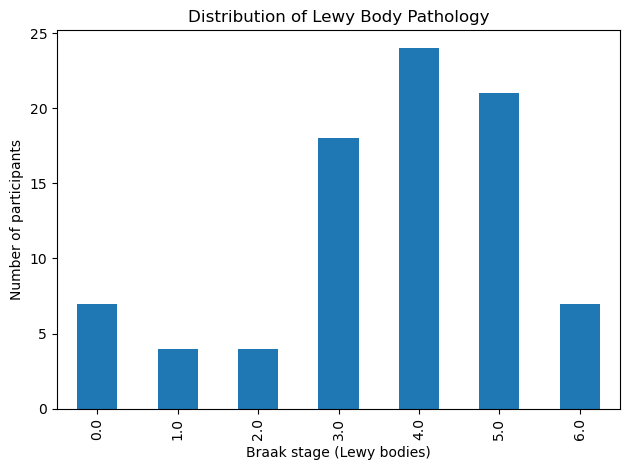

In [26]:
import matplotlib.pyplot as plt

plt.figure()
lb_counts.plot(kind="bar")

plt.xlabel("Braak stage (Lewy bodies)")
plt.ylabel("Number of participants")
plt.title("Distribution of Lewy Body Pathology")

plt.tight_layout()
plt.show()

In [28]:
df_plot2 = data_i.dropna(subset=["path_braak_nft"])

In [29]:
nft_counts = df_plot2["path_braak_nft"].value_counts().sort_index()

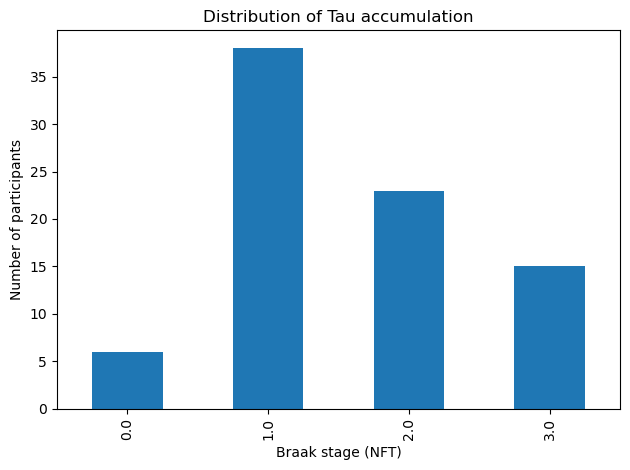

In [30]:
plt.figure()
nft_counts.plot(kind="bar")

plt.xlabel("Braak stage (NFT)")
plt.ylabel("Number of participants")
plt.title("Distribution of Tau accumulation")

plt.tight_layout()
plt.show()

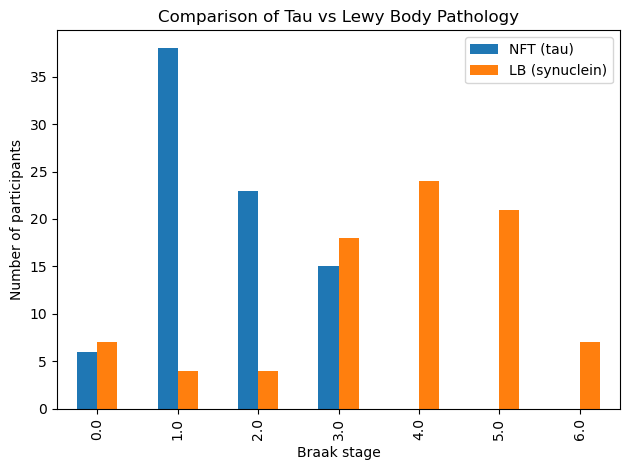

In [27]:
nft_counts = data_i["path_braak_nft"].value_counts().sort_index()
lb_counts  = data_i["path_braak_lb"].value_counts().sort_index()

df_counts = pd.DataFrame({
    "NFT (tau)": nft_counts,
    "LB (synuclein)": lb_counts
}).fillna(0)

df_counts.plot(kind="bar")

plt.xlabel("Braak stage")
plt.ylabel("Number of participants")
plt.title("Comparison of Tau vs Lewy Body Pathology")

plt.tight_layout()
plt.show()

In [33]:
braak_filtered["path_braak_lb"].dropna()

2521    5.0
2522    5.0
2523    5.0
2524    4.0
2525    4.0
       ... 
2605    6.0
2606    6.0
2608    4.0
2609    4.0
2610    5.0
Name: path_braak_lb, Length: 85, dtype: float64

In [37]:
braak_filtered["path_braak_lb"].unique()

array([ 5.,  4.,  3., nan,  2.,  1.,  0.,  6.])

In [29]:
# missing participant ids
set(participant_ids) - set(braak['participant_id'])

{'PM-UM_BEB18119',
 'PM-UM_HCTIX',
 'PM-UM_HCTNJ',
 'PM-UM_HCTTO',
 'PM-UM_HCTWJ',
 'PM-UM_HCTYE'}

In [3]:
clinical = pd.read_csv("/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/clinical_Terra_2024_v4_release_1027/LBD_Cohort_Clinical_Data.csv")

In [4]:
clinical

,participant_id,GUID,visit_name,visit_month,pres_symptom,fluc_cogn,vis_halluc,rbd,parkinsonism,neurolep_sens,...,mood_dis,auton_dys,dat,spect_pet_perf,exec_dys,memory_loss,mmse,anosmia,smell_detail,genetic
0,LB-00001,NaN,M0,0,Cognitive symptoms,NaN,Yes,No,Yes,NaN,...,Yes,No,NaN,NaN,NaN,Yes,15.0,NaN,NaN,NaN
1,LB-00002,NaN,M0,0,Cognitive symptoms,NaN,Yes,Yes,Yes,NaN,...,No,No,NaN,NaN,NaN,Yes,12.0,NaN,NaN,NaN
2,LB-00003,NaN,M0,0,Cognitive symptoms,Yes,Yes,Yes,Yes,Yes,...,No,No,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN
3,LB-00004,NaN,M0,0,Cognitive symptoms,NaN,Yes,No,Yes,NaN,...,No,No,NaN,Yes,NaN,Yes,12.0,NaN,NaN,NaN
4,LB-00005,NaN,M0,0,Cognitive symptoms,Yes,Yes,No,Yes,No,...,No,No,NaN,NaN,NaN,Yes,15.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2624,PM-UD_11353_001,NaN,SC#2,-84,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
2625,PM-UD_11353_001,NaN,SC#3,-48,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,27.0,NaN,NaN,NaN
2626,PM-UD_11353_001,NaN,SC#4,-12,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
2627,PM-UD_1052_001,NaN,SC#1,-48,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN


In [10]:
# filter the clinical data

clinical_filtered = clinical[clinical['participant_id'].isin(participant_ids)]

In [12]:
clinical_filtered

,participant_id,GUID,visit_name,visit_month,pres_symptom,fluc_cogn,vis_halluc,rbd,parkinsonism,neurolep_sens,...,mood_dis,auton_dys,dat,spect_pet_perf,exec_dys,memory_loss,mmse,anosmia,smell_detail,genetic
2521,PM-MS_17629,NaN,SC#1,-5,No,NaN,No,NaN,No,No,...,No,NaN,NaN,NaN,No,Yes,NaN,NaN,NaN,NaN
2522,PM-MS_46475,NaN,SC#1,-1,No,NaN,No,NaN,No,No,...,No,NaN,NaN,NaN,No,Yes,NaN,NaN,NaN,NaN
2523,PM-MS_458379,NaN,SC#1,-4,No,NaN,No,NaN,No,No,...,No,NaN,NaN,NaN,No,Yes,NaN,NaN,NaN,NaN
2524,PM-MS_616180,NaN,SC#1,-9,No,NaN,No,NaN,No,No,...,No,NaN,NaN,NaN,No,Yes,NaN,NaN,NaN,NaN
2525,PM-MS_840752,NaN,SC#1,-1,No,NaN,No,NaN,No,No,...,No,NaN,NaN,NaN,Yes,Yes,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2624,PM-UD_11353_001,NaN,SC#2,-84,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
2625,PM-UD_11353_001,NaN,SC#3,-48,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,27.0,NaN,NaN,NaN
2626,PM-UD_11353_001,NaN,SC#4,-12,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
2627,PM-UD_1052_001,NaN,SC#1,-48,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN


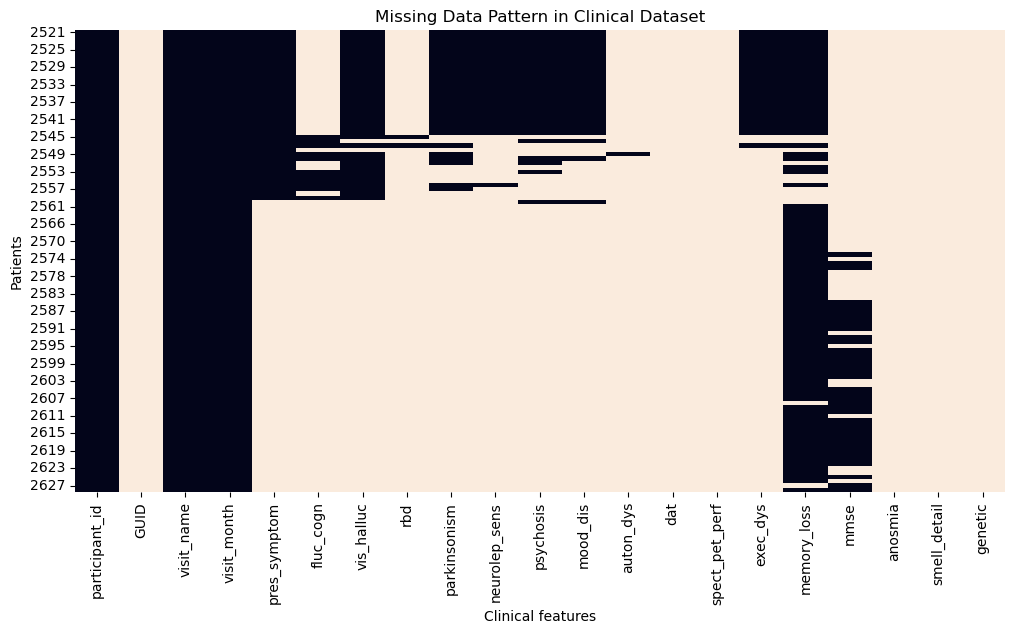

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(clinical_filtered.isna(), cbar=False)
plt.title("Missing Data Pattern in Clinical Dataset")
plt.xlabel("Clinical features")
plt.ylabel("Patients")
plt.show()

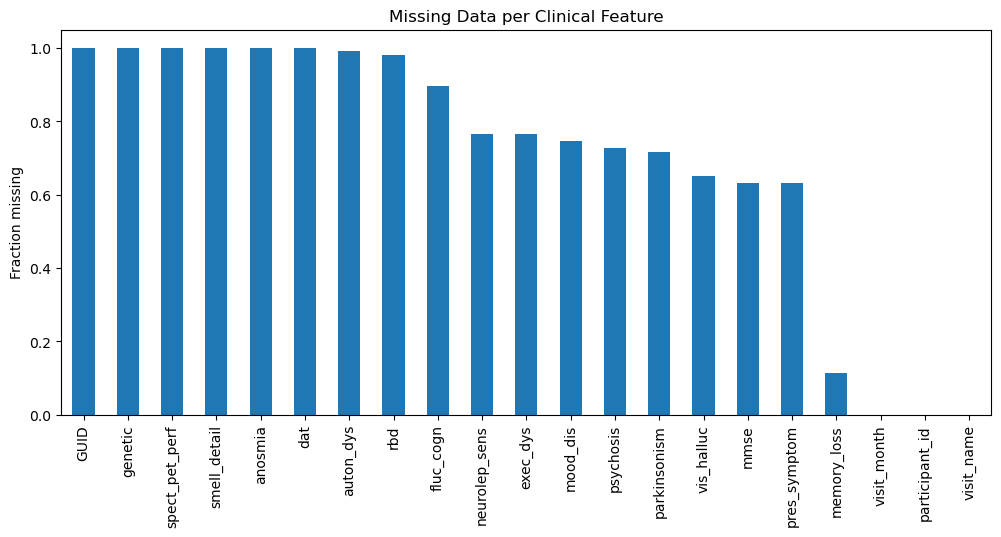

In [15]:
missing = clinical_filtered.isna().mean().sort_values(ascending=False)

missing.plot(kind="bar", figsize=(12,5))
plt.ylabel("Fraction missing")
plt.title("Missing Data per Clinical Feature")
plt.show()